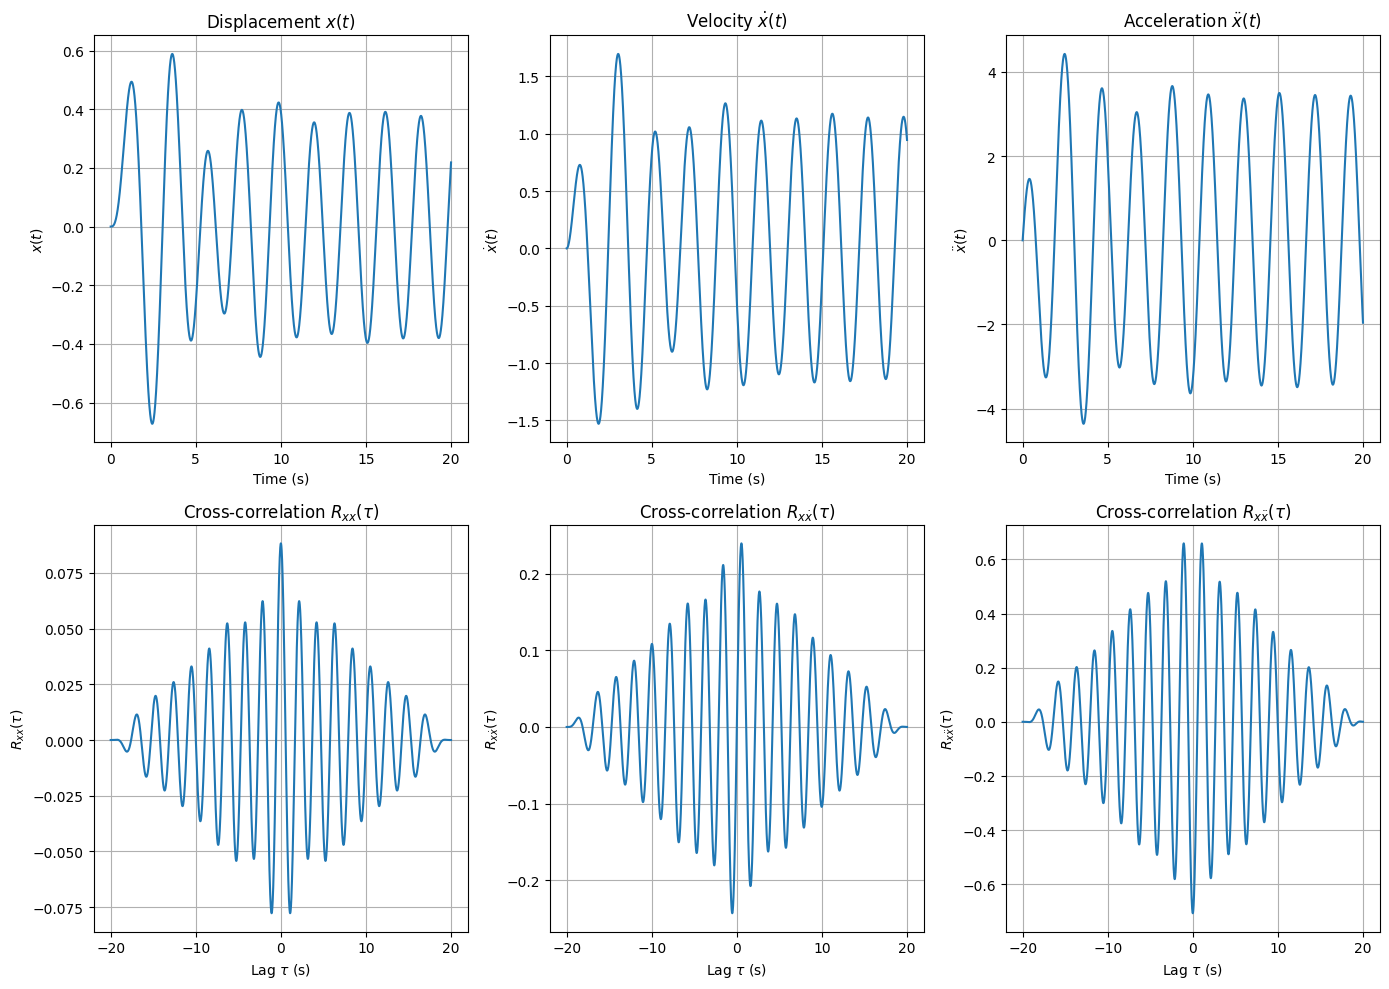

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Parameters
# --------------------------------------------------
m = 1.0
c = 0.5
k = 4.0

F0 = 2.0
omega = 3.0

dt = 0.001
t_end = 20.0
n = int(t_end / dt)

# Initial conditions
x0 = 0.0
v0 = 0.0

# --------------------------------------------------
# Arrays
# --------------------------------------------------
t = np.zeros(n + 1)
x = np.zeros(n + 1)
v = np.zeros(n + 1)
a = np.zeros(n + 1)
f = np.zeros(n + 1)

x[0] = x0
v[0] = v0

# Initial acceleration
f[0] = F0 * np.sin(omega * t[0])
a[0] = (f[0] - c * v[0] - k * x[0]) / m

# --------------------------------------------------
# Euler method
# --------------------------------------------------
for i in range(n):
    t[i + 1] = t[i] + dt
    f[i] = F0 * np.sin(omega * t[i])
    a[i] = (f[i] - c * v[i] - k * x[i]) / m

    x[i + 1] = x[i] + dt * v[i]
    v[i + 1] = v[i] + dt * a[i]

# Final acceleration
f[n] = F0 * np.sin(omega * t[n])
a[n] = (f[n] - c * v[n] - k * x[n]) / m

# --------------------------------------------------
# Remove mean before correlation
# --------------------------------------------------
x_zm = x - np.mean(x)
v_zm = v - np.mean(v)
a_zm = a - np.mean(a)

# --------------------------------------------------
# Cross-correlation function
# --------------------------------------------------
# Full correlation gives negative and positive lags
R_xx = np.correlate(x_zm, x_zm, mode='full') / len(x_zm)
R_xv = np.correlate(x_zm, v_zm, mode='full') / len(x_zm)
R_xa = np.correlate(x_zm, a_zm, mode='full') / len(x_zm)


# Lag vector
lags = np.arange(-len(x_zm) + 1, len(x_zm)) * dt

# --------------------------------------------------
# Plots
# --------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

# Signals
axes[0, 0].plot(t, x)
axes[0, 0].set_title(r'Displacement $x(t)$')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel(r'$x(t)$')
axes[0, 0].grid(True)

axes[0, 1].plot(t, v)
axes[0, 1].set_title(r'Velocity $\dot{x}(t)$')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel(r'$\dot{x}(t)$')
axes[0, 1].grid(True)

axes[0, 2].plot(t, a)
axes[0, 2].set_title(r'Acceleration $\ddot{x}(t)$')
axes[0, 2].set_xlabel('Time (s)')
axes[0, 2].set_ylabel(r'$\ddot{x}(t)$')
axes[0, 2].grid(True)

# Correlations
axes[1, 0].plot(lags, R_xx)
axes[1, 0].set_title(r'Cross-correlation $R_{x{x}}(\tau)$')
axes[1, 0].set_xlabel(r'Lag $\tau$ (s)')
axes[1, 0].set_ylabel(r'$R_{x{x}}(\tau)$')
axes[1, 0].grid(True)

axes[1, 1].plot(lags, R_xv)
axes[1, 1].set_title(r'Cross-correlation $R_{x\dot{x}}(\tau)$')
axes[1, 1].set_xlabel(r'Lag $\tau$ (s)')
axes[1, 1].set_ylabel(r'$R_{x\dot{x}}(\tau)$')
axes[1, 1].grid(True)

axes[1, 2].plot(lags, R_xa)
axes[1, 2].set_title(r'Cross-correlation $R_{x\ddot{x}}(\tau)$')
axes[1, 2].set_xlabel(r'Lag $\tau$ (s)')
axes[1, 2].set_ylabel(r'$R_{x\ddot{x}}(\tau)$')
axes[1, 2].grid(True)

# Empty subplot
# axes[1, 1].axis('off')

plt.tight_layout()
plt.show()